In [ ]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import os

from preprocessing_functions import normalize, clustering, clean_qc_columns

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

filename = os.path.join("..", "datasets", "GSM6592049_M2.h5ad")
os.makedirs(f"{os.path.dirname(filename)}_prepro", exist_ok=True) # Make sure the output directory exists

output_path_png = os.path.join(f"{os.path.dirname(filename)}_prepro", os.path.basename(filename).split(".h5")[0])
os.makedirs(output_path_png, exist_ok=True)
output_path_file = os.path.join(f"{os.path.dirname(filename)}_prepro", f"{os.path.basename(filename).split('.h5')[0]}_prepro.h5ad")


adata = sc.read_h5ad(filename)
adata = adata[adata.obs["in_tissue"] == True, :]
adata.var_names_make_unique()

# filtering low quality cells

13 mitochondrial genes


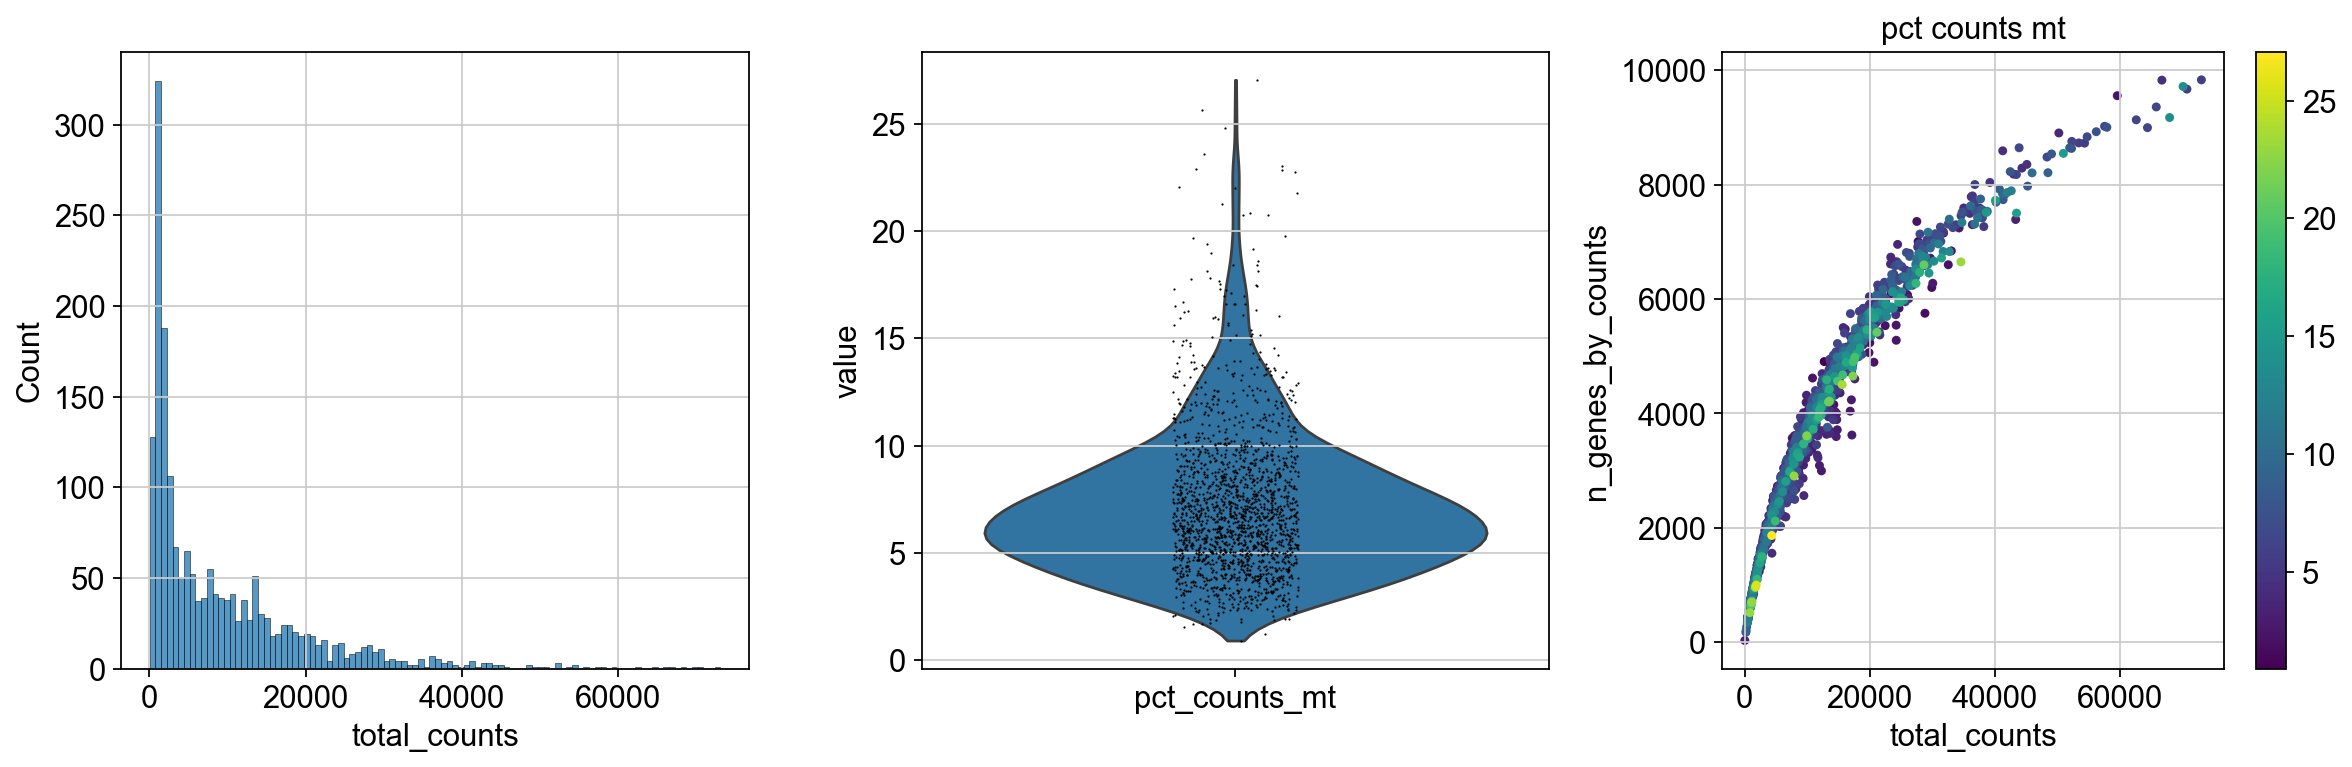

In [10]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(adata.var["mt"].sum(), "mitochondrial genes")

# calculate per-spot QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=[20], log1p=True)


# plot QC metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
sc.pl.violin(adata, "pct_counts_mt", ax=axes[1], show=False)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", ax=axes[2], show=False)

# Remove colorbars
for ax in fig.axes:
    if ax is not axes[0] and ax is not axes[1] and ax is not axes[2]:
        fig.delaxes(ax)

# Add your own colorbar
scatter_plot = axes[2].collections[0]
cbar = fig.colorbar(scatter_plot, ax=axes[2], location="right")

plt.tight_layout()

# Save to PNG
fig.savefig(os.path.join(output_path_png, "qc_plots.png"), dpi=300, bbox_inches="tight")  # high-res PNG

plt.show()

C:\Users\rebec\AppData\Local\Temp\ipykernel_23608\3678587644.py:24: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_23608\3678587644.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


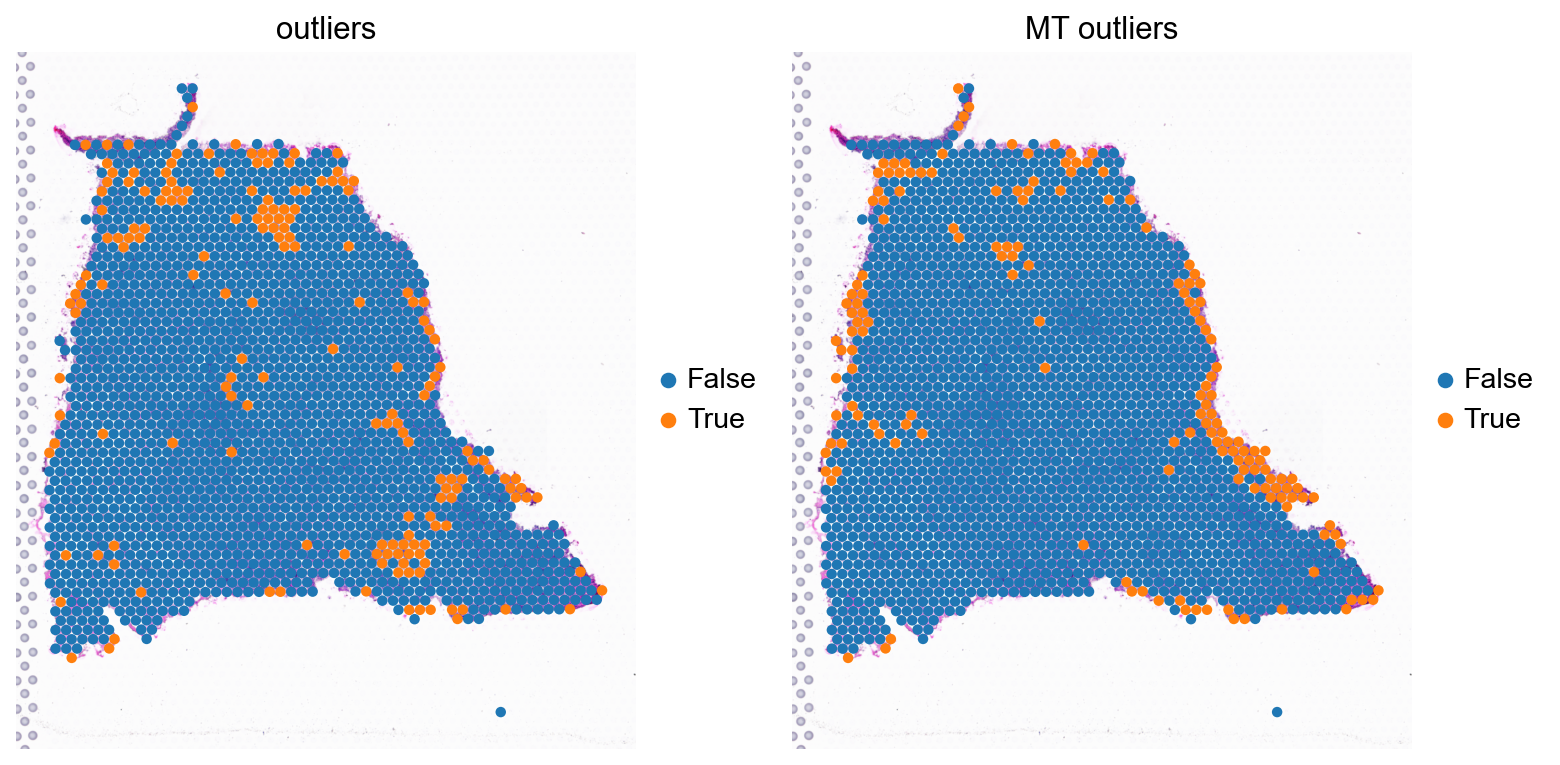

In [11]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

outlier_cutoff = 3
outlier_mt_cutoff = 3
outlier_mt_pct_cutoff = 12


adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", outlier_cutoff)
    | is_outlier(adata, "log1p_n_genes_by_counts", outlier_cutoff)
    | is_outlier(adata, "pct_counts_in_top_20_genes", outlier_cutoff)
)

adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", outlier_mt_cutoff) | (
    adata.obs["pct_counts_mt"] > outlier_mt_pct_cutoff
)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sc.pl.spatial(
    adata,
    color="outlier",
    library_id="GSM6592049_M2",
    size=1.5,
    title="outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="mt_outlier",
    library_id="GSM6592049_M2",
    size=1.5,
    title="MT outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()

# Save to PNG
fig.savefig(os.path.join(output_path_png, "outlier_spots.png"), dpi=300, bbox_inches="tight")  # high-res PNG

plt.show()

Total number of cells: 1848
Number of cells after filtering of low quality cells: 1568


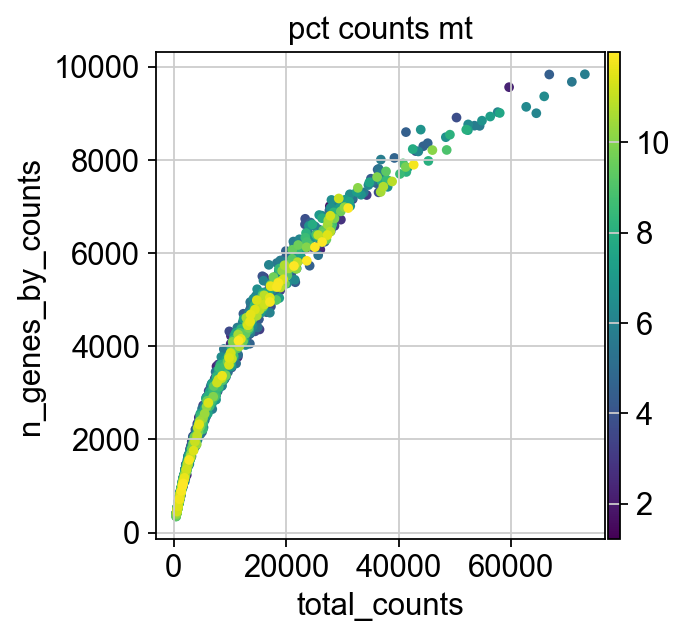

In [12]:
# We now filter our AnnData object based on these two additional columns.
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)

plt.savefig(os.path.join(output_path_png, "qc_covariate_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Data to write
lines = [
    "cutoffs for automatic thresholding and filtering based on MAD.",
    f"QC covariates: {outlier_cutoff}",
    f"Mt counts: {outlier_mt_cutoff}",
    "",
    f"cutoff percentage of mitochondrial counts: {outlier_mt_pct_cutoff}"
]

# Write to file
with open(os.path.join(output_path_png, "cutoffs.txt"), "w") as f:
    for line in lines:
        f.write(line + "\n")

In [14]:
normalize(adata)
clustering(adata)

clean_qc_columns(adata)

# added columns
# obs: 'leiden'
# uns: 'pca', 'neighbors', 'umap', 'leiden'
# obsm: 'spatial', 'X_pca', 'X_umap'
# varm: 'PCs'
# obsp: 'distances', 'connectivities' 

adata.write(output_path_file)